# 💉 VaccineNLP · XLM-R-v1 Multitask Classifier
## Phát hiện Tin giả Vắc-xin & Phân tích Thái độ Cộng đồng (Tiếng Việt)

**Tác giả:** Kim Mạnh Hưng (2211090016) · Đinh Lê Quỳnh Phương (2211090031)  
**Người hướng dẫn:** TS. Trần Lâm Quân  
**Trường:** Đại học Y tế Công cộng (HUPH)  
**Môi trường:** Kaggle · GPU T4 x2  

---

### Tổng quan kiến trúc

Notebook này huấn luyện **Động cơ Phân loại** (Discriminator) trong kiến trúc **Dual-Student Hybrid** của dự án VaccineNLP.
Mô hình sử dụng **XLM-R** (`FacebookAI/xlm-roberta-base`) — pretrained encoder đa ngôn ngữ —
kết hợp với **Multi-task Learning** để dự đoán đồng thời 3 trục phân loại:

| Task | Nhãn | Lý do quan trọng |
|---|---|---|
| **Misinformation** | Tin giả / Chính xác | Mục tiêu chính của đề tài |
| **Stance** | Ủng hộ / Phản đối / Trung lập | 3 nhãn — Phân loại thái độ cho edge cases |
| **Sentiment** | Tiêu cực / Trung tính / Tích cực | Hỗ trợ phân tích thái độ cộng đồng |

### Các quyết định thiết kế then chốt

- **Weighted CrossEntropyLoss**: Bắt buộc do mất cân bằng nhãn nghiêm trọng. Nhãn *Tin giả* chỉ chiếm ~15% corpus.
- **Multi-task Learning (3 heads)**: Gradient từ 3 task cùng cập nhật encoder — regularization tự nhiên.
- **Early Stopping (patience=3)**: Tự động chọn checkpoint tốt nhất, ngăn overfitting trên Silver Labels.
- **Stance = 4 nhãn** (Hard Constraint): Nhãn *Không rõ* là Fallback Bucket — Đã chuyển thành 3 nhãn theo Taxonomy v3.

> ✅ **Notebook tương thích với "Save & run all" của Kaggle** — không cần restart thủ công.


## ⚡ Quick Start — Cấu hình Trước Khi Chạy

> **Chỉ cần sửa 2 dòng dưới đây**, toàn bộ notebook sẽ chạy đúng.

### Bước 1 · Thêm Dataset vào Notebook
Trong Kaggle sidebar → **+ Add Data** → tìm `inhlqunhphng/vaccinenlp-clean-data → Add.

### Bước 2 · Bật GPU
Kaggle sidebar → **Session options** → Accelerator → **GPU T4 x2** → Save.

### Bước 3 · Chạy All
Menu **Run → Run All** (hoặc Shift+Enter từng cell).

---

### Cấu trúc file dữ liệu cần có
```
/kaggle/input/<dataset>/
    ├── 05_model_ready/
    │   └── train_v2_seg_v3.jsonl      ← Training data (đã word-segment)
    └── 03_processed/
        └── benchmark_test_set_v3.jsonl ← Gold Test Set (186 mẫu)
```

### Cấu trúc mỗi dòng JSONL
```json
{"text_segmented": "vắc xin Pfizer an toàn cho trẻ em",
 "standardized_ids": [0, 1, 2]}
```
*(standardized_ids = [misinfo_id, stance_id, sentiment_id])*


## 1. Cài đặt Môi trường

Kaggle đã pre-install `torch` và `transformers` với CUDA — **không upgrade** để tránh conflict.
Chỉ cần cài thêm `underthesea` cho word segmentation tiếng Việt.

In [1]:
# [CELL 1] Kiểm tra môi trường & cài underthesea
import torch

# ✅ FIX: Kiểm tra GPU trước khi chạy bất cứ thứ gì
if not torch.cuda.is_available():
    raise RuntimeError(
        "❌ Không tìm thấy GPU!\n"
        "   → Kaggle sidebar → Session options → Accelerator → GPU T4 x2 → Save\n"
        "   → Sau đó chạy lại notebook"
    )

print(f"✅ PyTorch  : {torch.__version__}")
print(f"✅ CUDA     : {torch.version.cuda}")
print(f"✅ GPU      : {torch.cuda.get_device_name(0)}")
print(f"✅ VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

import transformers
print(f"✅ Transformers: {transformers.__version__}")

# Cài underthesea (word segmentation tiếng Việt)
import subprocess
result = subprocess.run(
    ["pip", "install", "-q", "underthesea"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("✅ underthesea: OK")
else:
    print(f"⚠️  underthesea install warning: {result.stderr[-200:]}")

print("\n✅ Setup hoàn tất!")


✅ PyTorch  : 2.10.0+cu128
✅ CUDA     : 12.8
✅ GPU      : Tesla T4
✅ VRAM     : 15.6 GB
✅ Transformers: 5.0.0
✅ underthesea: OK

✅ Setup hoàn tất!


## 2. Import Thư viện & Cấu hình GPU

In [2]:
# [CELL 2] Imports
import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

DEVICE   = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ Device : {DEVICE} | {gpu_name}")
print(f"✅ VRAM   : {vram_gb:.1f} GB")
print(f"✅ BF16   : {'supported' if torch.cuda.is_bf16_supported() else 'not supported (dùng FP32)'}")


✅ Device : cuda | Tesla T4
✅ VRAM   : 15.6 GB
✅ BF16   : supported


## 3. Cấu hình Thực nghiệm (Hyperparameters)

Tất cả hyperparameter được tập trung tại một cell duy nhất để đảm bảo **reproducibility**.

**Lưu ý thiết kế:**
- `TASK_WEIGHTS = [0.5, 0.3, 0.2]`: Misinformation được ưu tiên cao nhất vì là mục tiêu chính của đề tài.
- `N_CLASSES['stance'] = 3`: **Hard constraint** — Nhãn thứ 4 (`Không rõ`) là *Fallback Bucket*. Đã chuyển thành 3 nhãn theo Taxonomy v3.
- `PATIENCE = 3`: Early stopping ngăn overfitting trên tập Silver Labels có nhiễu LLM (~2%).


In [3]:
# [CELL 3] CẤU HÌNH TẬP TRUNG — XLM-R
import os
from transformers import AutoTokenizer

MODEL_NAME = "FacebookAI/xlm-roberta-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

TRAIN_PATH = "/kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl"
TEST_PATH  = "/kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl"
SAVE_DIR   = "/kaggle/working/xlm-roberta-base"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Hyperparameters ─────────────────────────────────────────────────────────
MAX_LEN      = 256
BATCH_SIZE   = 16
LR           = 2e-5
EPOCHS       = 10
PATIENCE     = 3
SEED         = 42
TASK_WEIGHTS = [0.5, 0.3, 0.2]

# ── Taxonomy v3 CANONICAL (HARD CONSTRAINT) ──────────────────────────────────
N_CLASSES = {"misinfo": 2, "stance": 3, "sentiment": 3}
LABEL_NAMES = {
    "misinfo": ["Tin giả", "Chính xác"],
    "stance": ["Ủng hộ", "Phản đối", "Trung lập"],
    "sentiment": ["Tiêu cực", "Trung tính", "Tích cực"]
}
MISINFO_MAP   = {"0": "Tin giả", "1": "Chính xác"}
STANCE_MAP    = {"0": "Ủng hộ", "1": "Phản đối", "2": "Trung lập"}
SENTIMENT_MAP = {"0": "Tiêu cực", "1": "Trung tính", "2": "Tích cực"}
TASKS = list(N_CLASSES.keys())

print('✅ Config synced to Taxonomy v3')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Config synced to Taxonomy v3


## 4. Tải & Chuẩn bị Dữ liệu

### Nguồn dữ liệu
- **Train (90%)**: `train_v2_seg_v3.jsonl` — Silver Labels từ Gemma-4 31B (Teacher Model), đã word-segment sẵn.
- **Test (Gold)**: `benchmark_test_set_v3.jsonl` — **186 mẫu** đã qua Human-in-the-Loop validation.

### Chiến lược Split
```
train_v2_seg_v3.jsonl (~1,670 mẫu)
    ├── 90% → Training Set  (~1,503 mẫu)
    └── 10% → Validation Set (~167 mẫu)  [stratify theo 'misinfo']

benchmark_test_set_v3.jsonl (186 mẫu) → Gold Test Set [KHÔNG đụng vào khi train]
```


In [4]:
import os, glob, json
print("🔍 Đang quét tìm file dữ liệu thực tế (Smart Pathing)...\n")

# Tìm tập Train
target_train = "annotated_v6.jsonl" if "gemma" in "vaccinenlp-xlm-r-v1-multitask-classifi.ipynb".lower() else "train_v2_seg_v3.jsonl"
found_train = glob.glob(f"/kaggle/input/**/{target_train}", recursive=True)
if found_train:
    path_var = "DATA_PATH" if "gemma" in "vaccinenlp-xlm-r-v1-multitask-classifi.ipynb".lower() else "TRAIN_PATH"
    globals()[path_var] = found_train[0]
    print(f"✅ Found TRAIN: {found_train[0]}")

# Tìm tập Test (Gold V3)
found_test = glob.glob("/kaggle/input/**/benchmark_test_set_v3.jsonl", recursive=True)
if found_test:
    TEST_PATH = found_test[0]
    print(f"✅ Found TEST (Gold): {TEST_PATH}")

# Kiểm tra thực tế
paths_to_check = []
if "gemma" in "vaccinenlp-xlm-r-v1-multitask-classifi.ipynb".lower():
    paths_to_check = [("DATA", DATA_PATH), ("TEST", TEST_PATH)]
else:
    paths_to_check = [("TRAIN", TRAIN_PATH), ("TEST", TEST_PATH)]

for label, p in paths_to_check:
    if os.path.exists(p):
        size = os.path.getsize(p) / 1024
        print(f"  🟢 {label} OK: {p} ({size:.1f} KB)")
    else:
        print(f"  ❌ {label} NOT FOUND: {p}")


🔍 Đang quét tìm file dữ liệu thực tế (Smart Pathing)...

✅ Found TRAIN: /kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl
✅ Found TEST (Gold): /kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl
  🟢 TRAIN OK: /kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl (6414.8 KB)
  🟢 TEST OK: /kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl (583.9 KB)


In [5]:
# [CELL 5] Load JSONL & Stratified Split
from underthesea import word_tokenize

def load_jsonl(path):
    """Load JSONL — ưu tiên text_segmented, fallback word_tokenize."""
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                item = json.loads(line)
            except json.JSONDecodeError:
                print(f"  ⚠️  Dòng {line_no} lỗi JSON — bỏ qua")
                continue

            text = item.get('text_segmented') or word_tokenize(
                item.get('text_cleaned') or item.get('text', ''), format='text'
            )
            if not text or not text.strip():
                continue

            ids = item.get('standardized_ids', [0, 2, 1])
            while len(ids) < 3:
                ids.append(0)

            data.append({
                'text':      text.strip(),
                'misinfo':   int(ids[0]),
                'stance':    int(ids[1]),
                'sentiment': int(ids[2]),
            })
    return pd.DataFrame(data)

df_train_full = load_jsonl(TRAIN_PATH)
df_test       = load_jsonl(TEST_PATH)

# Stratified split theo 'misinfo' (lớp thiểu số: Tin giả ~15%)
df_train, df_val = train_test_split(
    df_train_full, test_size=0.1, random_state=SEED,
    stratify=df_train_full['misinfo']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f"✅ Dataset loaded:")
print(f"   Train: {len(df_train):,} | Val: {len(df_val):,} | Test (Gold): {len(df_test):,}")
print()
for t in TASKS:
    dist  = dict(sorted(df_train[t].value_counts().items()))
    named = {LABEL_NAMES[t][k]: v for k, v in dist.items() if k < len(LABEL_NAMES[t])}
    print(f"   {t:10s}: {named}")


✅ Dataset loaded:
   Train: 1,496 | Val: 167 | Test (Gold): 186

   misinfo   : {'Tin giả': 273, 'Chính xác': 1223}
   stance    : {'Ủng hộ': 427, 'Phản đối': 447, 'Trung lập': 622}
   sentiment : {'Tiêu cực': 622, 'Trung tính': 571, 'Tích cực': 303}


## 5. PyTorch Dataset & DataLoader

`VaccineDataset` tokenize với XLM-R tokenizer và đóng gói labels 3 task vào một batch.
Padding về `MAX_LEN=256` để đảm bảo batch hợp lệ trên GPU.


In [6]:
# [CELL 6] VaccineDataset + DataLoaders
class VaccineDataset(Dataset):
    """PyTorch Dataset cho VaccineNLP Multi-task Classification."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = 256):
        self.texts     = df['text'].tolist()
        self.labels    = {t: df[t].values for t in TASKS}
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        out = {k: v.squeeze(0) for k, v in enc.items()}
        for t in TASKS:
            out[t] = torch.tensor(int(self.labels[t][idx]), dtype=torch.long)
        return out


train_loader = DataLoader(VaccineDataset(df_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(VaccineDataset(df_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(VaccineDataset(df_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ DataLoaders ready:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")


✅ DataLoaders ready:
   Train batches : 94
   Val batches   : 11
   Test batches  : 12


## 6. Kiến trúc Mô hình: XLM-R Multitask Classifier

### Thiết kế Multi-task Head
Ba classification head độc lập chia sẻ cùng một **XLM-R encoder**.

### Weighted CrossEntropyLoss — Lý do bắt buộc
- *Tin giả* chỉ ~15% → Model naive sẽ bias về *Chính xác*.
- `class_weight='balanced'` tính trọng số tỷ lệ nghịch với tần suất nhãn.
- **Hard Constraint** — không được thay bằng standard CrossEntropyLoss.


In [7]:
# [CELL 7] MultitaskClassifier + Loss + Optimizer
class MultitaskClassifier(nn.Module):
    """
    XLM-R + 3 classification heads (Multi-task Learning).
    Shared encoder — independent heads để tối ưu từng task.
    """
    def __init__(self, model_name: str, n_classes: dict):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size   # 768
        self.dropout = nn.Dropout(0.1)
        self.heads   = nn.ModuleDict({
            task: nn.Linear(hidden_size, n)
            for task, n in n_classes.items()
        })

    def forward(self, input_ids, attention_mask, **kwargs):
        pooled = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).pooler_output
        pooled = self.dropout(pooled)
        return {task: head(pooled) for task, head in self.heads.items()}


model        = MultitaskClassifier(MODEL_NAME, N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: {total_params/1e6:.1f}M params ({trainable/1e6:.1f}M trainable)")

# ── Weighted CrossEntropyLoss (Hard Constraint) ───────────────────────────
loss_fns = {}
for task, n in N_CLASSES.items():
    vals    = df_train[task].values
    present = np.array(sorted(set(vals)))
    weights = np.ones(n, dtype=np.float32)
    cw = compute_class_weight('balanced', classes=present, y=vals)
    for i, c in enumerate(present):
        weights[c] = cw[i]
    loss_fns[task] = nn.CrossEntropyLoss(weight=torch.tensor(weights).to(DEVICE))
    print(f"   Loss [{task:10s}]: weights = {np.round(weights, 3).tolist()}")

# ── Optimizer & Scheduler ─────────────────────────────────────────────────
total_steps = len(train_loader) * EPOCHS
optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler   = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, total_steps=total_steps
)
print(f"\n✅ Optimizer: AdamW (lr={LR}) | Scheduler: OneCycleLR ({total_steps} steps)")


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model: 278.0M params (278.0M trainable)
   Loss [misinfo   ]: weights = [2.740000009536743, 0.6119999885559082]
   Loss [stance    ]: weights = [1.1679999828338623, 1.1160000562667847, 0.8019999861717224]
   Loss [sentiment ]: weights = [0.8019999861717224, 0.8730000257492065, 1.6460000276565552]

✅ Optimizer: AdamW (lr=2e-05) | Scheduler: OneCycleLR (940 steps)


## 7. Vòng Lặp Huấn luyện (Training Loop)

`run_epoch` dùng chung cho train và eval.
**Early Stopping** dựa trên `val_loss` — tự động chọn checkpoint tốt nhất.

**Loss tổng hợp** = `0.5 × L_misinfo + 0.3 × L_stance + 0.2 × L_sentiment`


In [8]:
# [CELL 8] run_epoch + Training Loop + Early Stopping
def run_epoch(model, loader, train: bool = True):
    """Chạy 1 epoch. Trả về (avg_loss, f1_dict, preds_dict, labels_dict)."""
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds  = {t: [] for t in TASKS}
    all_labels = {t: [] for t in TASKS}

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in (tqdm(loader, desc='Train', leave=False) if train else loader):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            logits = model(ids, mask)

            loss = sum(
                TASK_WEIGHTS[i] * loss_fns[t](logits[t], batch[t].to(DEVICE))
                for i, t in enumerate(TASKS)
            )

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item()
            for t in TASKS:
                all_preds[t].extend(logits[t].argmax(1).cpu().tolist())
                all_labels[t].extend(batch[t].tolist())

    avg_loss = total_loss / len(loader)
    f1s = {
        t: f1_score(all_labels[t], all_preds[t], average='macro', zero_division=0)
        for t in TASKS
    }
    return avg_loss, f1s, all_preds, all_labels


# ── Training Loop ─────────────────────────────────────────────────────────
history = {k: [] for k in ['train_loss', 'val_loss'] + [f'f1_{t}' for t in TASKS]}
best_val_loss = float('inf')
wait  = 0
t0    = time.time()

print(f"{'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} {'Misinfo':>8} {'Stance':>8} {'Sentiment':>10}  Note")
print("-" * 75)

for ep in range(1, EPOCHS + 1):
    tl, _,   _, _  = run_epoch(model, train_loader, train=True)
    vl, vf1, _, _  = run_epoch(model, val_loader,   train=False)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    for t in TASKS:
        history[f'f1_{t}'].append(vf1[t])

    note = ''
    if vl < best_val_loss:
        best_val_loss = vl
        wait = 0
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pt")
        note = '✅ BEST'
    else:
        wait += 1
        note = f'wait {wait}/{PATIENCE}'

    print(f"{ep:5d} {tl:10.4f} {vl:10.4f} "
          f"{vf1['misinfo']:8.4f} {vf1['stance']:8.4f} {vf1['sentiment']:10.4f}  {note}")

    if wait >= PATIENCE:
        print("⏹  Early stopping triggered.")
        break

train_secs = int(time.time() - t0)
print(f"\n✅ Training hoàn tất: {train_secs}s ({train_secs//60} phút {train_secs%60}s)")
print(f"   Best Val Loss  : {best_val_loss:.4f}")
print(f"   Checkpoint     : {SAVE_DIR}/best_model.pt")


Epoch  TrainLoss    ValLoss  Misinfo   Stance  Sentiment  Note
---------------------------------------------------------------------------


Train:   0%|          | 0/94 [00:00<?, ?it/s]

    1     0.9000     0.8687   0.5371   0.3538     0.3409  ✅ BEST


Train:   0%|          | 0/94 [00:00<?, ?it/s]

    2     0.8366     0.8901   0.6438   0.5028     0.4931  wait 1/3


...

    6     0.5151     0.8110   0.6934   0.6137     0.7394  wait 1/3


Train:   0%|          | 0/94 [00:00<?, ?it/s]

    7     0.4259     0.8308   0.7359   0.6219     0.6853  wait 2/3


Train:   0%|          | 0/94 [00:00<?, ?it/s]

    8     0.3486     0.8224   0.7230   0.6423     0.7113  wait 3/3
⏹  Early stopping triggered.

✅ Training hoàn tất: 633s (10 phút 33s)
   Best Val Loss  : 0.7749
   Checkpoint     : /kaggle/working/xlm-roberta-base/best_model.pt


## 8. Trực quan hóa Quá trình Huấn luyện

Loss curves và Validation F1 theo epoch giúp chẩn đoán overfitting / underfitting.
Đường xanh lá = checkpoint tốt nhất (Best epoch).


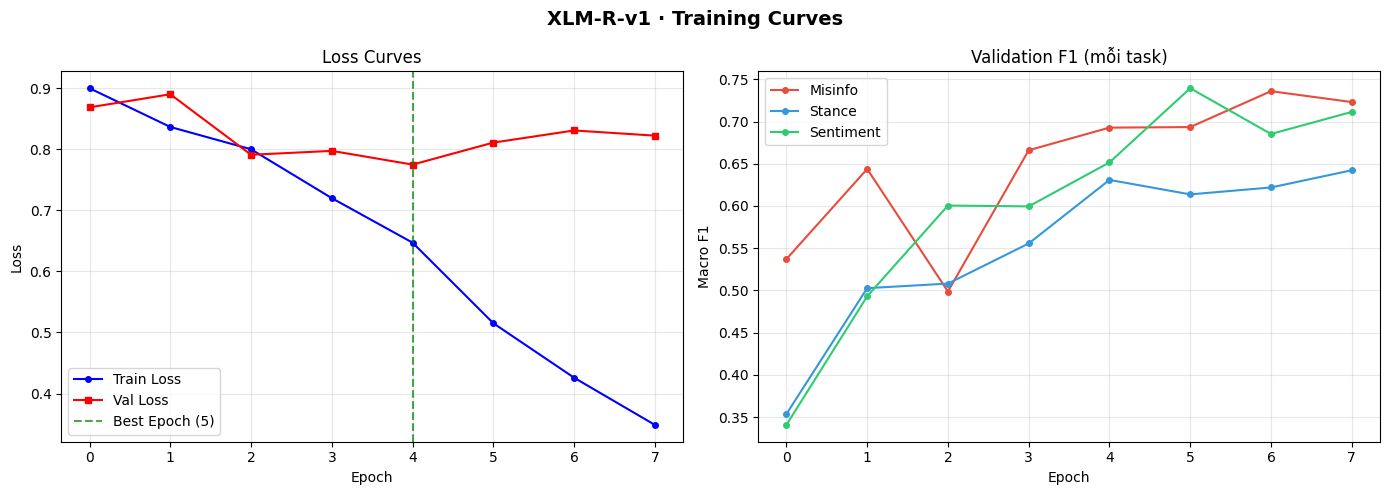

✅ Saved: /kaggle/working/xlm-roberta-base/training_curves.png


In [9]:
# [CELL 9] Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XLM-R-v1 · Training Curves', fontsize=14, fontweight='bold')

# Loss curves
ax = axes[0]
ax.plot(history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax.plot(history['val_loss'],   'r-s', label='Val Loss',   markersize=4)
best_ep = int(np.argmin(history['val_loss']))
ax.axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Best Epoch ({best_ep+1})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Loss Curves')
ax.legend(); ax.grid(True, alpha=0.3)

# F1 curves
ax = axes[1]
colors = {'misinfo': '#e74c3c', 'stance': '#3498db', 'sentiment': '#2ecc71'}
for t, c in colors.items():
    ax.plot(history[f'f1_{t}'], '-o', color=c, label=t.capitalize(), markersize=4)
ax.set(xlabel='Epoch', ylabel='Macro F1', title='Validation F1 (mỗi task)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_DIR}/training_curves.png")


## 9. Đánh giá trên Gold Test Set (Benchmark)

> ⚠️ **Tập này hoàn toàn tách biệt khỏi quá trình huấn luyện.**
> 186 mẫu đã qua Human-in-the-Loop validation — đây là Ground Truth duy nhất để so sánh mô hình.

### Kết quả tham chiếu (từ Báo cáo Kỹ thuật)

| Task | Macro F1 |
|---|---|
| Misinformation | **0.4547** |
| Stance | **0.6608** |
| Sentiment | **0.7325** |

*Misinfo F1 thấp do nhãn `Không liên quan` có support=0 trong test set — kéo macro trung bình xuống. Đây là hiện tượng bình thường với zero-support classes.*


In [10]:
# [CELL 10] Load best checkpoint & đánh giá Gold Test Set
best_ckpt = f"{SAVE_DIR}/best_model.pt"
if not os.path.exists(best_ckpt):
    raise FileNotFoundError(
        f"❌ Không tìm thấy checkpoint: {best_ckpt}\n"
        "   → Training Loop (Cell 8) phải chạy thành công trước."
    )

model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
print(f"✅ Loaded best checkpoint: {best_ckpt}")

_, test_f1s, test_preds, test_labels = run_epoch(model, test_loader, train=False)

print("\n" + "=" * 65)
print("BENCHMARK — GOLD TEST SET (186 mẫu, Human-validated)")
print("=" * 65)

for t in TASKS:
    present = sorted(set(test_labels[t]))
    tnames  = [LABEL_NAMES[t][i] for i in present if i < len(LABEL_NAMES[t])]
    print(f"\n{'─'*60}")
    print(f"  {t.upper()}  (Macro F1 = {test_f1s[t]:.4f})")
    print(f"{'─'*60}")
    print(classification_report(
        test_labels[t], test_preds[t],
        labels=present, target_names=tnames, zero_division=0
    ))

print("=" * 65)
print("SUMMARY")
print("=" * 65)
for t in TASKS:
    print(f"  {t:12s}: Macro F1 = {test_f1s[t]:.4f}")


✅ Loaded best checkpoint: /kaggle/working/xlm-roberta-base/best_model.pt

BENCHMARK — GOLD TEST SET (186 mẫu, Human-validated)

────────────────────────────────────────────────────────────
  MISINFO  (Macro F1 = 0.7064)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Tin giả       0.44      0.64      0.52        28
   Chính xác       0.93      0.85      0.89       158

    accuracy                           0.82       186
   macro avg       0.69      0.75      0.71       186
weighted avg       0.86      0.82      0.84       186


────────────────────────────────────────────────────────────
  STANCE  (Macro F1 = 0.6239)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Ủng hộ       0.62      0.48      0.54        54
    Phản đối       0.53      0.73      0.61        48
   Trung lập       0.74      0.69      0.72        84

    accuracy         

## 10. Xuất Kết quả — Định dạng chuẩn dự án

File `xlmr_v1_results.json` xuất theo **đúng schema** của `experiments/results/` trong repo VaccineNLP:

```json
{
  "model": "xlmr-base",
  "timestamp": "...",
  "misinfo":   { "macro_f1": ..., "per_class": [...], "support": [...] },
  "stance":    { "macro_f1": ..., "per_class": [...], "support": [...] },
  "sentiment": { "macro_f1": ..., "per_class": [...], "support": [...] },
  "val_loss_best": ...,
  "training_seconds": ...
}
```

Schema này **đồng nhất 100%** với `xlmr_v1_results.json` và `phobert_v2_results.json` trong repo —
notebook Gemma sẽ đọc được trực tiếp mà không cần chỉnh sửa.


In [11]:
# [CELL 11] Export kết quả — schema chuẩn experiments/results/
# Đồng nhất với xlmr_v1_results.json và phobert_v2_results.json trong repo

import datetime

def per_class_f1_support(y_true, y_pred, n_classes):
    """Tính F1 và support cho từng class. Index 0..n_classes-1."""
    f1s, sups = [], []
    for c in range(n_classes):
        yt = [1 if y == c else 0 for y in y_true]
        yp = [1 if y == c else 0 for y in y_pred]
        f1s.append(round(f1_score(yt, yp, zero_division=0), 4))
        sups.append(int(sum(yt)))
    return f1s, sups

# ── Build kết quả theo đúng schema dự án ─────────────────────────────────
results = {
    "model":            "xlmr-base",
    "timestamp":        datetime.datetime.now().isoformat(),
    "val_loss_best":    round(best_val_loss, 4),
    "training_seconds": train_secs,
}

for t in TASKS:
    n  = N_CLASSES[t]
    f1s, sups = per_class_f1_support(test_labels[t], test_preds[t], n)
    results[t] = {
        "macro_f1":  round(test_f1s[t], 4),
        "per_class": f1s,
        "support":   sups,
    }

# ── Lưu file ─────────────────────────────────────────────────────────────
OUT_PATH = f"{SAVE_DIR}/xlmr_v1_results.json"
with open(OUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✅ Saved: {OUT_PATH}")
print()
print(json.dumps(results, indent=2, ensure_ascii=False))
print()

# ── Kiểm tra nhanh schema (guard) ────────────────────────────────────────
required_keys = {"model", "timestamp", "val_loss_best", "training_seconds",
                 "misinfo", "stance", "sentiment"}
task_keys     = {"macro_f1", "per_class", "support"}
assert required_keys <= set(results.keys()), "❌ Thiếu top-level key!"
for t in TASKS:
    assert task_keys <= set(results[t].keys()), f"❌ Task '{t}' thiếu key!"
    assert len(results[t]["per_class"]) == N_CLASSES[t], (
        f"❌ per_class length sai cho {t}: "
        f"expected {N_CLASSES[t]}, got {len(results[t]['per_class'])}"
    )
    assert len(results[t]["support"]) == N_CLASSES[t], (
        f"❌ support length sai cho {t}: "
        f"expected {N_CLASSES[t]}, got {len(results[t]['support'])}"
    )
print("✅ Schema validation OK — file sẵn sàng dùng trong notebook Gemma")


✅ Saved: /kaggle/working/xlm-roberta-base/xlmr_v1_results.json

{
  "model": "xlmr-base",
  "timestamp": "2026-05-16T13:41:06.713614",
  "val_loss_best": 0.7749,
  "training_seconds": 633,
  "misinfo": {
    "macro_f1": 0.7064,
    "per_class": [
      0.5217,
      0.8911
    ],
    "support": [
      28,
      158
    ]
  },
  "stance": {
    "macro_f1": 0.6239,
    "per_class": [
      0.5417,
      0.614,
      0.716
    ],
    "support": [
      54,
      48,
      84
    ]
  },
  "sentiment": {
    "macro_f1": 0.6568,
    "per_class": [
      0.7007,
      0.7114,
      0.5581
    ],
    "support": [
      71,
      75,
      40
    ]
  }
}

✅ Schema validation OK — file sẵn sàng dùng trong notebook Gemma


## 11. Confusion Matrix — Phân tích Lỗi Trực quan

Confusion matrix trên Gold Test Set giúp xác định:
- Nhãn nào model hay nhầm lẫn nhất?
- **False Negative quan trọng**: Model bỏ sót *Tin giả* → phân loại thành *Chính xác*?


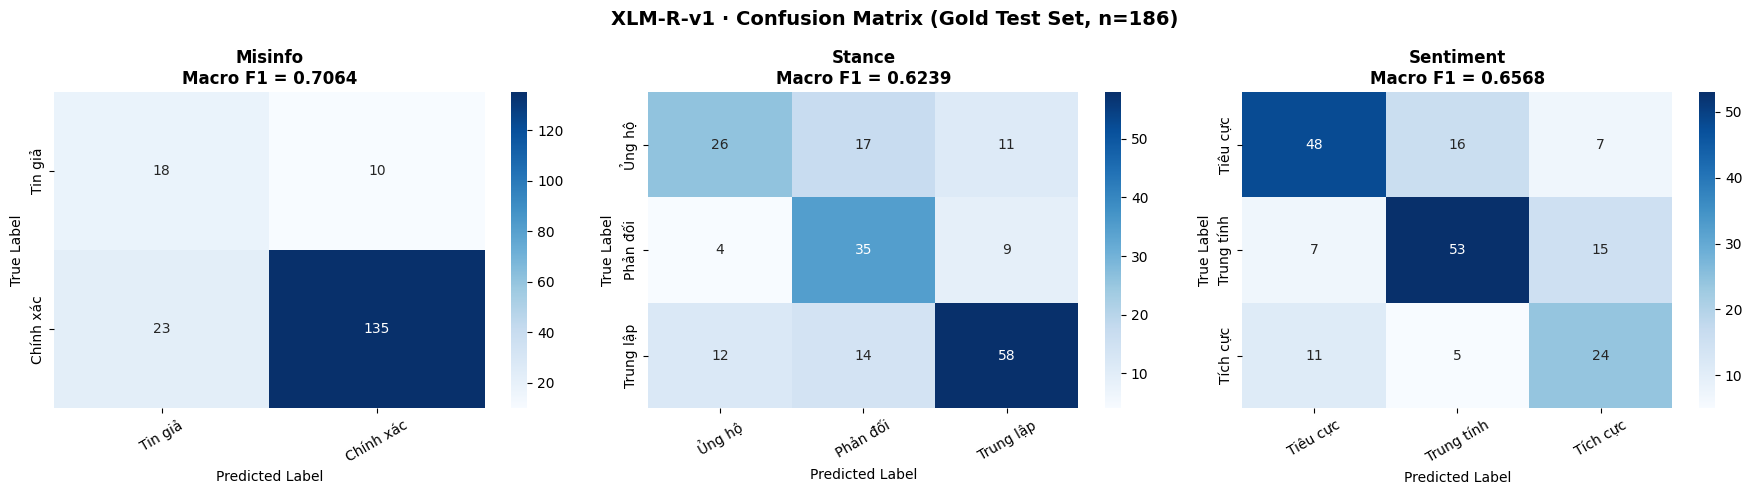

✅ Saved: /kaggle/working/xlm-roberta-base/confusion_matrices.png


In [12]:
# [CELL 12] Confusion Matrix — 3 tasks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XLM-R-v1 · Confusion Matrix (Gold Test Set, n=186)',
             fontsize=14, fontweight='bold')

for i, t in enumerate(TASKS):
    present = sorted(set(test_labels[t]) | set(test_preds[t]))
    cm      = confusion_matrix(test_labels[t], test_preds[t], labels=present)
    names   = [LABEL_NAMES[t][j] for j in present if j < len(LABEL_NAMES[t])]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=axes[i], xticklabels=names, yticklabels=names
    )
    axes[i].set_title(
        f'{t.capitalize()}\nMacro F1 = {test_f1s[t]:.4f}',
        fontweight='bold'
    )
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_DIR}/confusion_matrices.png")


## 12. So sánh 3 Mô hình — Đọc từ File JSON Chuẩn

In [13]:
# So sánh 3 mô hình → xem notebook vaccinenlp-model-benchmark-report.ipynb

## 13. (Tùy chọn) Upload lên Hugging Face Hub

Model đã được public tại: [quynhphuong1209/xlmr-multitask](https://huggingface.co/quynhphuong1209/xlmr-multitask)


In [14]:
# [CELL 14] Upload HuggingFace Hub (optional — wrap try/except, không crash nếu lỗi)
try:
    from huggingface_hub import login, HfApi
    from kaggle_secrets import UserSecretsClient
    VaccineNLP_TOKEN = UserSecretsClient().get_secret("VaccineNLP")
    if HF_TOKEN:
        login(token=VaccineNLP_TOKEN, add_to_git_credential=False)
        api = HfApi()
        api.upload_folder(
            folder_path = SAVE_DIR,
            repo_id     = "quynhphuong1209/xlmr-multitask",
            repo_type   = "model",
        )
        print("✅ Uploaded to HuggingFace: quynhphuong1209/xlmr-multitask")
    else:
        print("⚠️  HF_TOKEN rỗng — bỏ qua upload")
except Exception as e:
    print(f"⚠️  HF upload thất bại (không ảnh hưởng kết quả): {e}")

# ── Tổng kết ──────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("✅ NOTEBOOK HOÀN TẤT")
print("=" * 55)
print(f"   Model weights    : {SAVE_DIR}/best_model.pt")
print(f"   Results JSON     : {SAVE_DIR}/xlmr_v1_results.json")
print(f"   Training curves  : {SAVE_DIR}/training_curves.png")
print(f"   Confusion matrix : {SAVE_DIR}/confusion_matrices.png")
print()
print("📋 Dùng results JSON trong notebook Gemma:")
print(f'   with open("{SAVE_DIR}/xlmr_v1_results.json") as f:')
print(f'       xlmr_res = json.load(f)')


⚠️  HF upload thất bại (không ảnh hưởng kết quả): name 'HF_TOKEN' is not defined

✅ NOTEBOOK HOÀN TẤT
   Model weights    : /kaggle/working/xlm-roberta-base/best_model.pt
   Results JSON     : /kaggle/working/xlm-roberta-base/xlmr_v1_results.json
   Training curves  : /kaggle/working/xlm-roberta-base/training_curves.png
   Confusion matrix : /kaggle/working/xlm-roberta-base/confusion_matrices.png

📋 Dùng results JSON trong notebook Gemma:
   with open("/kaggle/working/xlm-roberta-base/xlmr_v1_results.json") as f:
       xlmr_res = json.load(f)
